In [1]:
# !pip install datasets

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

/home/renata/miniforge3/envs/pln-pd/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("ag_news")

Generating test split: 100%|██████████| 7600/7600 [00:00<00:00, 402788.86 examples/s]


In [3]:
df = dataset["train"].to_pandas()[:10000]

mapa_categorias = {0: "mundo", 1: "esportes", 2: "negócios", 3: "tecnologia"}

df["categoria"] = df["label"].map(mapa_categorias)

In [4]:
df.iloc[0]

text         Wall St. Bears Claw Back Into the Black (Reute...
label                                                        2
categoria                                             negócios
Name: 0, dtype: object

In [5]:
mundo = df[df["categoria"] == "mundo"]
esportes = df[df["categoria"] == "esportes"]
negocios = df[df["categoria"] == "negócios"]
tecnologia = df[df["categoria"] == "tecnologia"]

In [6]:
mundo

,text,label,categoria
492,Venezuelans Vote Early in Referendum on Chavez...,0,mundo
493,S.Koreans Clash with Police on Iraq Troop Disp...,0,mundo
494,Palestinians in Israeli Jails Start Hunger Str...,0,mundo
495,Seven Georgian soldiers wounded as South Osset...,0,mundo
496,Rwandan Troops Arrive in Darfur (AP) AP - Doze...,0,mundo
...,...,...,...
9954,JCC Arson Roils French Jews Jewish leaders exp...,0,mundo
9962,Hicks confirms abuse allegations ACCUSED Austr...,0,mundo
9972,BA boss admits 'we got it wrong' British Airwa...,0,mundo
9989,"N.B. truck driver accused in heist of 50,000 c...",0,mundo


In [7]:
esportes

,text,label,categoria
448,"Phelps, Thorpe Advance in 200 Freestyle (AP) A...",1,esportes
449,Reds Knock Padres Out of Wild-Card Lead (AP) A...,1,esportes
450,"Dreaming done, NBA stars awaken to harsh Olymp...",1,esportes
451,"Indians Beat Twins 7-1, Nearing AL Lead (AP) A...",1,esportes
452,"Galaxy, Crew Play to 0-0 Tie (AP) AP - Kevin H...",1,esportes
...,...,...,...
9973,Dirrell Boosts American Title Hopes in Boxing ...,1,esportes
9984,"Athletics: For Greeks, hurdles offer redemptio...",1,esportes
9985,Wrestling: Cinderella in Sydney suffers turnab...,1,esportes
9986,"Jana vows to return JANA Pittman, the girl who...",1,esportes


In [8]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=2000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['text'])

In [9]:
words = tfidf_vectorizer.get_feature_names_out()


In [10]:
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=words)

In [11]:
df_tfidf.iloc[10].sort_values(ascending=False)

outlook    0.481138
economy    0.419652
soaring    0.267265
plus       0.248412
worries    0.248412
             ...   
fast       0.000000
far        0.000000
fans       0.000000
family     0.000000
fell       0.000000
Name: 10, Length: 2000, dtype: float64

In [12]:
df.iloc[10]

text         Oil and Economy Cloud Stocks' Outlook  NEW YOR...
label                                                        2
categoria                                             negócios
Name: 10, dtype: object

In [13]:
df_tfidf.iloc[mundo.index].mean().sort_values(ascending=False)

ap             0.028687
najaf          0.027600
reuters        0.024608
iraq           0.024515
said           0.024488
                 ...   
nec            0.000000
yahoo          0.000000
woods          0.000000
integration    0.000000
worm           0.000000
Length: 2000, dtype: float64

In [14]:
df_tfidf.iloc[esportes.index].mean().sort_values(ascending=False)

39            0.053458
athens        0.049605
olympic       0.044845
gold          0.043544
ap            0.035952
                ...   
militant      0.000000
militants     0.000000
militia       0.000000
militiamen    0.000000
serif         0.000000
Length: 2000, dtype: float64

In [15]:
df_tfidf.mean().sort_values(ascending=False)

39           0.032863
reuters      0.022797
ap           0.022541
new          0.019958
said         0.017252
               ...   
messaging    0.000571
ottawa       0.000563
hd           0.000556
scream       0.000544
oslo         0.000527
Length: 2000, dtype: float64

In [16]:
words

array(['000', '10', '100', ..., 'yukos', 'zealand', 'ziff'],
      shape=(2000,), dtype=object)

In [17]:
tf_vectorizer = CountVectorizer(vocabulary=words)

tf_matrix = tf_vectorizer.fit_transform(df['text'])

In [18]:
df_tf = pd.DataFrame(tf_matrix.toarray(), columns=words)

In [19]:
idf = tfidf_vectorizer.idf_

In [20]:
tf_mundo = df_tf.iloc[mundo.index].sum()
tf_esportes = df_tf.iloc[esportes.index].sum()
tf_negocios = df_tf.iloc[negocios.index].sum()
tf_tecnologia = df_tf.iloc[tecnologia.index].sum()

c_tf_idf_mundo = (tf_mundo * idf)
c_tf_idf_esportes = (tf_esportes * idf)
c_tf_idf_negocios = (tf_negocios * idf)
c_tf_idf_tecnologia = (tf_tecnologia * idf)

In [21]:
c_tf_idf_mundo.sort_values(ascending=False)

najaf      2057.919694
ap         1871.017036
iraq       1723.387252
said       1706.464039
reuters    1692.015025
              ...     
woods         0.000000
cycling       0.000000
giants        0.000000
www           0.000000
crm           0.000000
Length: 2000, dtype: float64

In [22]:
c_tf_idf_esportes.sort_values(ascending=False)

39            2888.831401
athens        2723.515547
olympic       2465.166953
gold          2396.364678
ap            1990.298633
                 ...     
bird             0.000000
blair            0.000000
private          0.000000
serif            0.000000
properties       0.000000
Length: 2000, dtype: float64

In [23]:
c_tf_idf_negocios.sort_values(ascending=False)

oil             2997.486097
reuters         2967.360793
39              2351.138462
prices          2059.354237
stocks          2000.840906
                   ...     
oslo               0.000000
palestinians       0.000000
palestinian        0.000000
cardinals          0.000000
captain            0.000000
Length: 2000, dtype: float64

In [24]:
c_tf_idf_tecnologia.sort_values(ascending=False)

new          1686.781308
microsoft    1643.550241
lt           1568.727154
gt           1561.755747
ap           1526.804430
                ...     
citigroup       0.000000
cink            0.000000
nepalese        0.000000
nepal           0.000000
yukos           0.000000
Length: 2000, dtype: float64

In [25]:
!pip install wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 12.9 MB/s  0:00:00


In [28]:
from wordcloud import WordCloud


def plot_wordcloud(c_tf_idf):
    wordcloud = WordCloud(
        background_color="white",
        max_words=100,
        max_font_size=30,
        min_font_size=10,
        prefer_horizontal=1,
        width=300,
        height=150
    )
    return wordcloud.generate_from_frequencies(c_tf_idf)


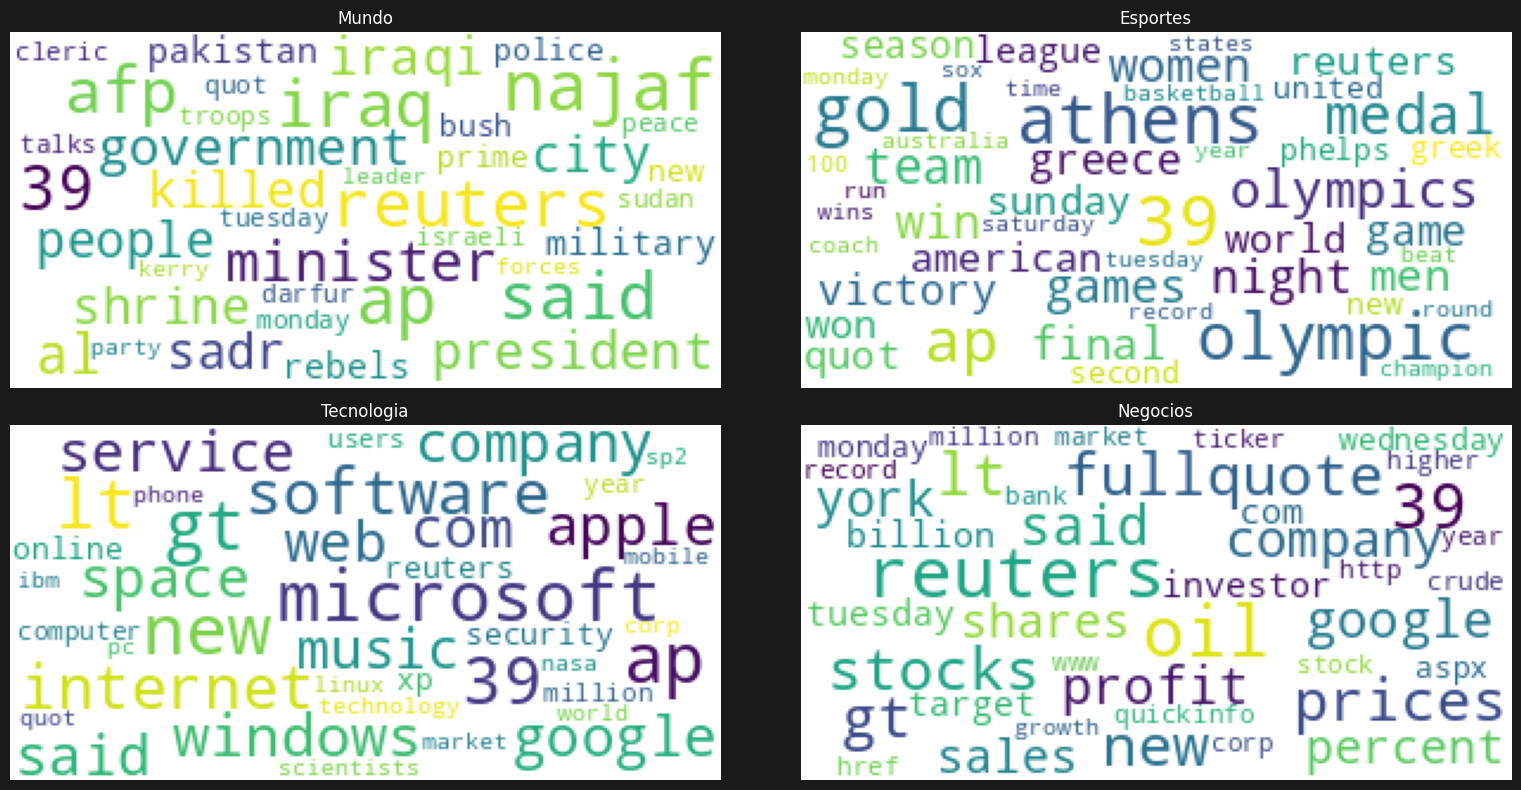

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes[0][0].imshow(plot_wordcloud(c_tf_idf_mundo.to_dict()))
axes[0][0].axis('off')
axes[0][0].set_title("Mundo")
axes[0][1].imshow(plot_wordcloud(c_tf_idf_esportes.to_dict()))
axes[0][1].axis('off')
axes[0][1].set_title("Esportes")
axes[1][0].imshow(plot_wordcloud(c_tf_idf_tecnologia.to_dict()))
axes[1][0].axis('off')
axes[1][0].set_title("Tecnologia")
axes[1][1].imshow(plot_wordcloud(c_tf_idf_negocios.to_dict()))
axes[1][1].axis('off')
axes[1][1].set_title("Negocios")

plt.tight_layout()
